In [1]:
pip install scikit-learn matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [24]:
df = pd.read_excel("C:/Users/rayif/OneDrive/Desktop/student-dropout-prediction/data.xlsx")

df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   object 
 2   Application order                               4424 non-null   object 
 3   Course                                          4424 non-null   object 
 4   Daytime/evening attendance                      4424 non-null   object 
 5   Previous qualification                          4424 non-null   object 
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   object 
 8   Mother's qualification                          4424 non-null   object 
 9   Father's qualification                   

Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

C:\Users\rayif\AppData\Local\Temp\ipykernel_21632\707593634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


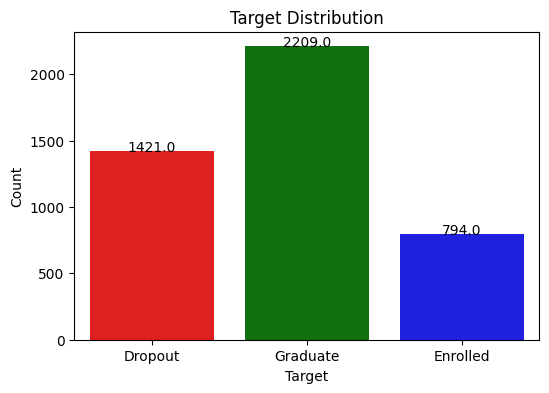

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Target',
    data=df,
    palette=['red', 'green', 'blue']
)

# Show values on top
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center'
    )

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

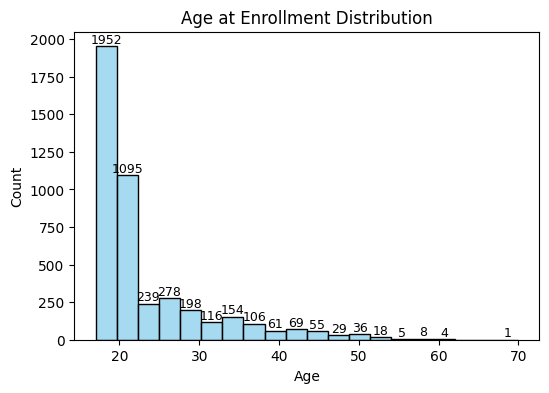

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.histplot(df['Age at enrollment'], bins=20, color='skyblue')

# Show count values on top of bars
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:  # avoid showing 0 values
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title("Age at Enrollment Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

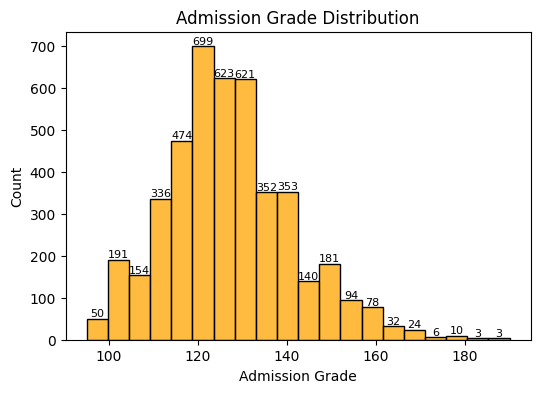

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.histplot(df['Admission grade'], bins=20, color='orange')

# Show count values
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title("Admission Grade Distribution")
plt.xlabel("Admission Grade")
plt.ylabel("Count")
plt.show()

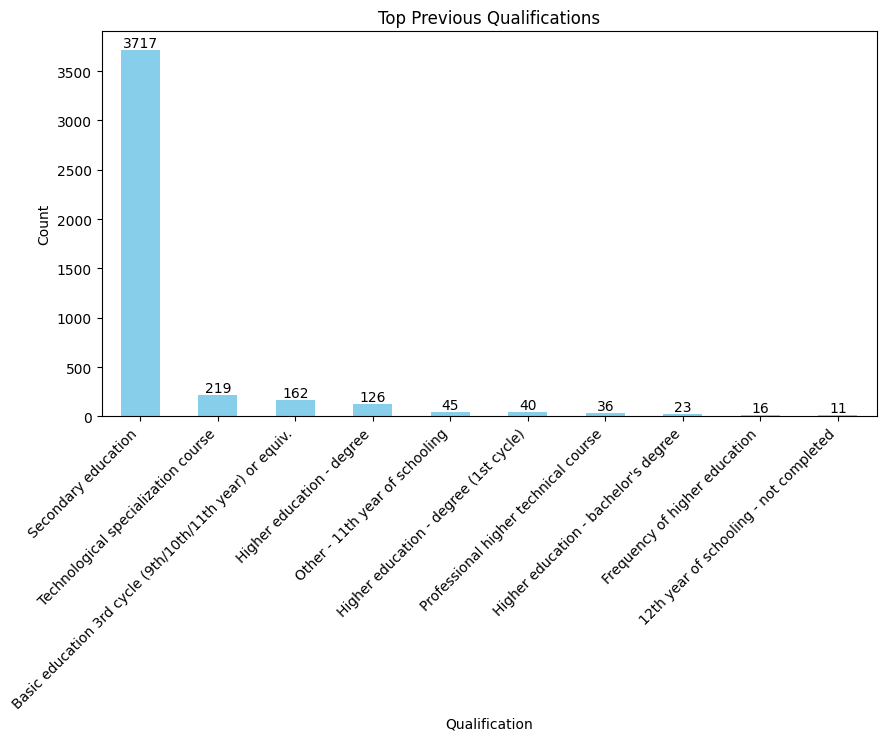

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

top10 = df['Previous qualification'].value_counts().head(10)

ax = top10.plot(kind='bar', color='skyblue')

# Show values on top of bars
for i, value in enumerate(top10):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.title("Top Previous Qualifications")
plt.xlabel("Qualification")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

C:\Users\rayif\AppData\Local\Temp\ipykernel_21632\998318491.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


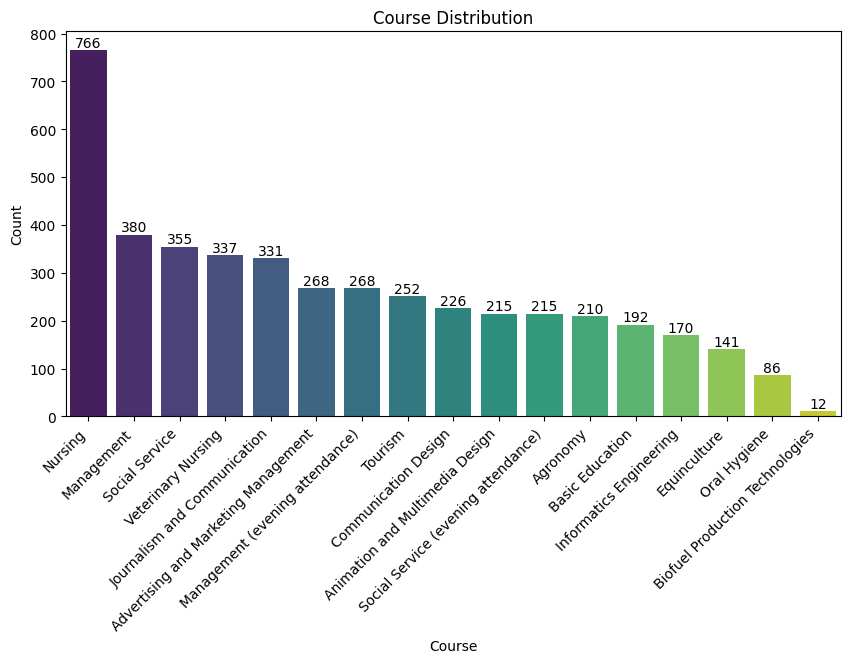

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

course_counts = df['Course'].value_counts()

ax = sns.barplot(
    x=course_counts.index,
    y=course_counts.values,
    palette='viridis'
)

# Show values on top of each bar
for i, value in enumerate(course_counts.values):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.title("Course Distribution")
plt.xlabel("Course")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

C:\Users\rayif\AppData\Local\Temp\ipykernel_21632\2187321396.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


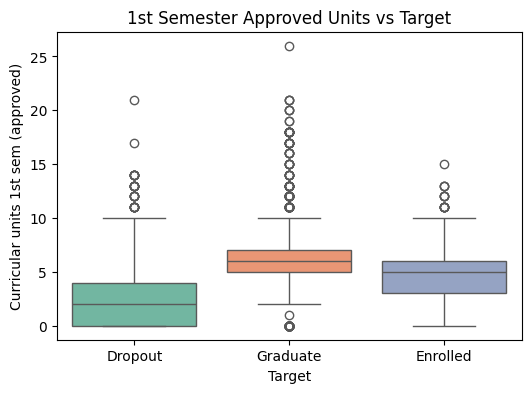

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.boxplot(
    x='Target',
    y='Curricular units 1st sem (approved)',   # change column name if needed
    data=df,
    palette='Set2'
)

plt.title("1st Semester Approved Units vs Target")
plt.show()

C:\Users\rayif\AppData\Local\Temp\ipykernel_21632\595151616.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


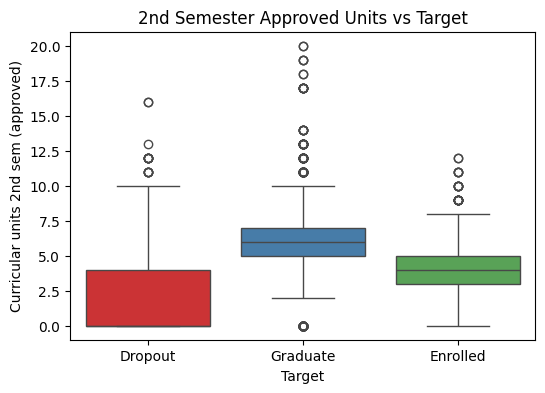

In [10]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='Target',
    y='Curricular units 2nd sem (approved)',  # change if needed
    data=df,
    palette='Set1'
)

plt.title("2nd Semester Approved Units vs Target")
plt.show()

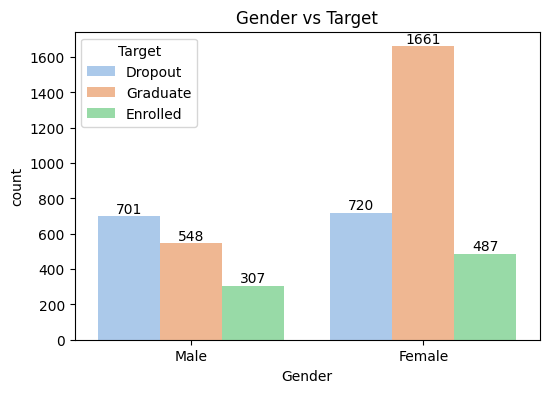

In [11]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Gender',
    hue='Target',
    data=df,
    palette='pastel'
)

# Show values
for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender vs Target")
plt.show()

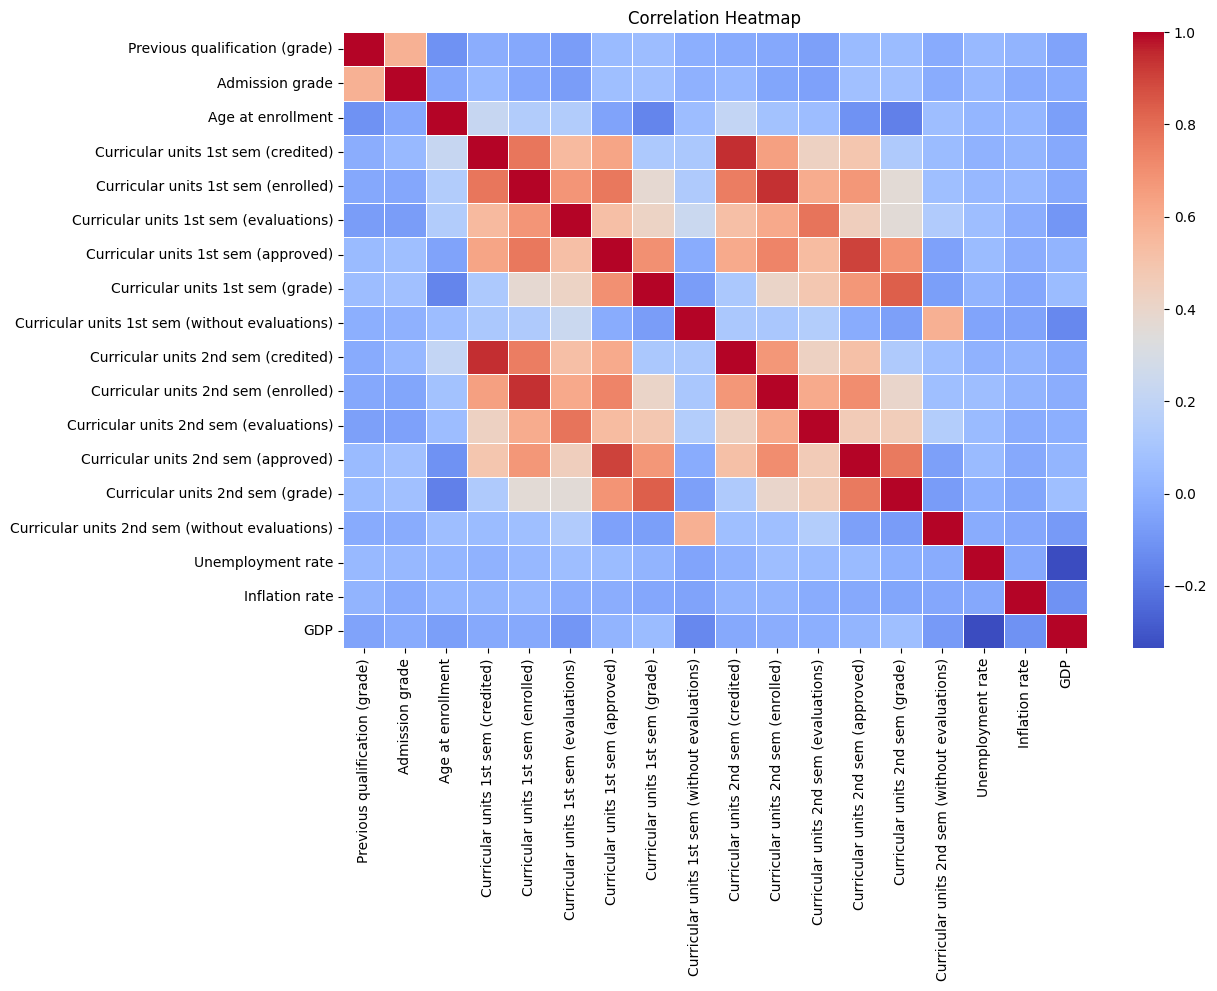

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

# Select only numerical columns
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=False,        # keep False if too many features
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

#### Preprocessing — Missing Values & Drop Columns

In [13]:
# Check missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else '✅ No missing values found!')

Missing values per column:
✅ No missing values found!


In [14]:
# Check duplicates
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed. New shape: {df.shape}')

Duplicate rows: 0


In [15]:
# Drop macroeconomic columns — not student-specific, not actionable for early intervention
cols_to_drop = ['Unemployment rate', 'Inflation rate', 'GDP']
df.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped: {cols_to_drop}')
print(f'Remaining shape: {df.shape}')

Dropped: ['Unemployment rate', 'Inflation rate', 'GDP']
Remaining shape: (4424, 34)


## Feature Engineering

In [16]:
# New Feature 1: Total units approved across both semesters
df['Total_Approved'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']

# New Feature 2: Average grade across both semesters
df['Avg_Grade'] = (df['Curricular units 1st sem (grade)'] + df['Curricular units 2nd sem (grade)']) / 2

# New Feature 3: Approval rate — what fraction of enrolled units did the student pass
total_enrolled = df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']
df['Approval_Rate'] = df['Total_Approved'] / total_enrolled.replace(0, np.nan)
df['Approval_Rate'].fillna(0, inplace=True)

# New Feature 4: Total evaluations across both semesters
df['Total_Evaluations'] = df['Curricular units 1st sem (evaluations)'] + df['Curricular units 2nd sem (evaluations)']

print('✅ Feature Engineering done!')
print('New features: Total_Approved, Avg_Grade, Approval_Rate, Total_Evaluations')
df[['Total_Approved', 'Avg_Grade', 'Approval_Rate', 'Total_Evaluations']].describe()

✅ Feature Engineering done!
New features: Total_Approved, Avg_Grade, Approval_Rate, Total_Evaluations


C:\Users\rayif\AppData\Local\Temp\ipykernel_21632\722905922.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Approval_Rate'].fillna(0, inplace=True)


,Total_Approved,Avg_Grade,Approval_Rate,Total_Evaluations
count,4424.000000,4424.000000,4424.000000,4424.000000
mean,9.142405,10.435514,0.679076,16.362342
std,5.960612,4.818530,0.361945,7.664986
min,0.000000,0.000000,0.000000,0.000000
25%,5.000000,11.000000,0.500000,13.000000
50%,10.000000,12.250000,0.833333,16.000000
75%,12.000000,13.266667,1.000000,20.000000
max,43.000000,18.283654,1.000000,72.000000


## Encoding

In [17]:
# Label Encode the Target
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_Encoded'] = df['Target'].map(target_mapping)
print('Target Mapping:', target_mapping)
print(df['Target_Encoded'].value_counts())

Target Mapping: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
Target_Encoded
2    2209
0    1421
1     794
Name: count, dtype: int64


In [18]:
# One-Hot Encode nominal categorical columns
ohe_cols = [
    'Marital Status', 'Application mode', 'Course', 'Daytime/evening attendance',
    'Previous qualification', 'Nacionality', "Mother's qualification",
    "Father's qualification", "Mother's occupation", "Father's occupation"
]

df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f'Shape after One-Hot Encoding: {df_encoded.shape}')

Shape after One-Hot Encoding: (4424, 241)


In [21]:
df_encoded.dtypes

Application order                                                                                           object
Previous qualification (grade)                                                                             float64
Admission grade                                                                                            float64
Displaced                                                                                                   object
Educational special needs                                                                                   object
                                                                                                            ...   
Father's occupation_Unskilled Workers                                                                         bool
Father's occupation_Unskilled workers in agriculture, animal production, fisheries and forestry               bool
Father's occupation_Unskilled workers in extractive industry, construction, manu

In [25]:
# Label Encode remaining binary string columns (e.g. Yes/No, Male/Female)
le = LabelEncoder()
binary_str_cols = [c for c in df_encoded.select_dtypes(include='object').columns if c != 'Target']
for col in binary_str_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print(f'Label-encoded binary columns: {binary_str_cols}')

# Drop original target string column
df_encoded.drop(columns=['Target'], inplace=True)

# Final X and y
X = df_encoded.drop(columns=['Target_Encoded'])
y = df_encoded['Target_Encoded']

print(f'\nFinal Features Shape : {X.shape}')
print(f'Target Shape         : {y.shape}')

Label-encoded binary columns: ['Application order', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Final Features Shape : (4424, 239)
Target Shape         : (4424,)


## Train-Test Split & Scaling

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set : {X_train.shape}')
print(f'Testing set  : {X_test.shape}')
print('✅ Split and scaled!')

Training set : (3539, 239)
Testing set  : (885, 239)
✅ Split and scaled!


## Model Selection

In [27]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0)
}

print('✅ Models defined:', list(models.keys()))

✅ Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## Train All Models & Compare

In [29]:
results = []

for name, model in models.items():
    # Logistic Regression needs scaled data
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f'{name:<22} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}')

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n--- Ranked Results ---')
results_df

Logistic Regression    | Acc: 0.7514 | Prec: 0.7358 | Rec: 0.7514 | F1: 0.7401
Decision Tree          | Acc: 0.7435 | Prec: 0.7317 | Rec: 0.7435 | F1: 0.7355
Random Forest          | Acc: 0.7797 | Prec: 0.7647 | Rec: 0.7797 | F1: 0.7639
Gradient Boosting      | Acc: 0.7740 | Prec: 0.7615 | Rec: 0.7740 | F1: 0.7651
XGBoost                | Acc: 0.7684 | Prec: 0.7583 | Rec: 0.7684 | F1: 0.7615

--- Ranked Results ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.779661,0.764664,0.779661,0.763891
1,Gradient Boosting,0.774011,0.761539,0.774011,0.765102
2,XGBoost,0.768362,0.758254,0.768362,0.761461
3,Logistic Regression,0.751412,0.735805,0.751412,0.740097
4,Decision Tree,0.743503,0.731678,0.743503,0.735484


## Feature Importance

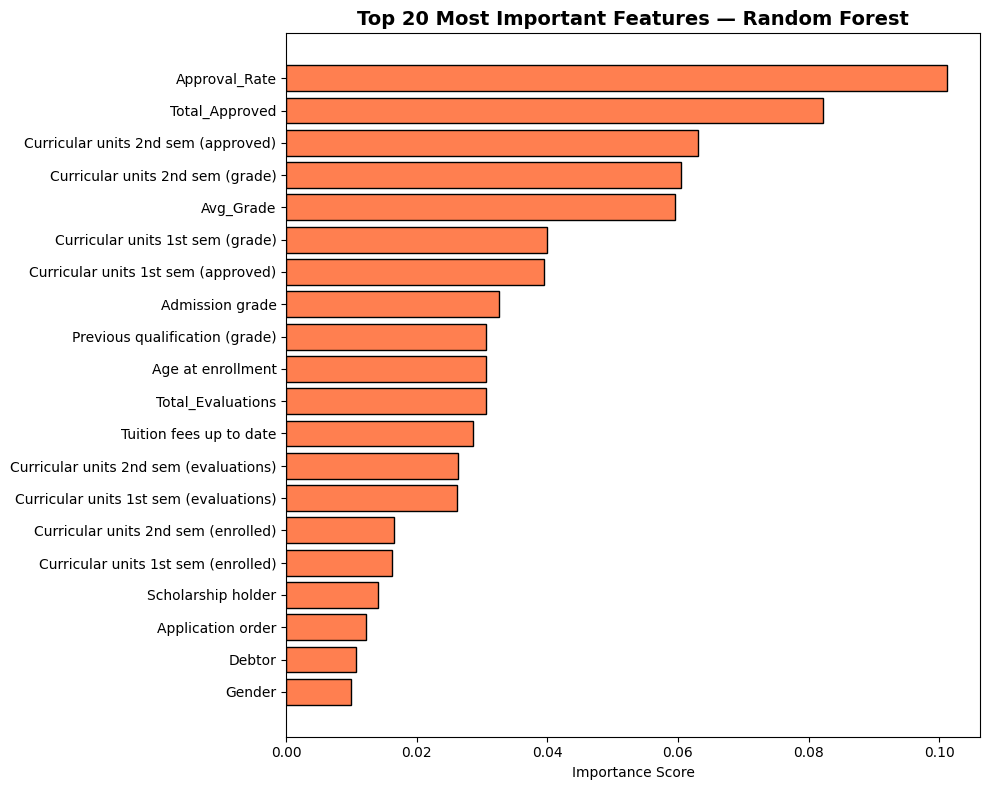

In [31]:
# Random Forest Feature Importance (comparison)
rf_imp = pd.DataFrame({'Feature': X.columns, 'Importance': models['Random Forest'].feature_importances_})
rf_imp = rf_imp.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(rf_imp['Feature'][::-1], rf_imp['Importance'][::-1], color='coral', edgecolor='black')
plt.title('Top 20 Most Important Features — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Final Summary

In [33]:
print('=' * 62)
print('       FINAL MODEL COMPARISON — ALL METRICS')
print('=' * 62)
print(results_df.to_string(index=False))
best = results_df.iloc[0]
print(f'\n🏆 Best Model : {best["Model"]}')
print(f'   Accuracy   : {best["Accuracy"]:.4f}')
print(f'   Precision  : {best["Precision"]:.4f}')
print(f'   Recall     : {best["Recall"]:.4f}')
print(f'   F1-Score   : {best["F1-Score"]:.4f}')

       FINAL MODEL COMPARISON — ALL METRICS
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.779661   0.764664 0.779661  0.763891
  Gradient Boosting  0.774011   0.761539 0.774011  0.765102
            XGBoost  0.768362   0.758254 0.768362  0.761461
Logistic Regression  0.751412   0.735805 0.751412  0.740097
      Decision Tree  0.743503   0.731678 0.743503  0.735484

🏆 Best Model : Random Forest
   Accuracy   : 0.7797
   Precision  : 0.7647
   Recall     : 0.7797
   F1-Score   : 0.7639
